In [1]:
%load_ext autoreload
%autoreload 2
from pc_training import TracePCTrainConfig, PCInferenceConfig, train_trace_model, evaluate_trace_model
import seaborn as sns
import matplotlib.pyplot as plt
from dataloader import TraceDataset
import numpy as np
from torch.utils.data import DataLoader
import torch
from torch.nn import functional as F

In [ ]:
inference = PCInferenceConfig(
    n_steps=20,
    step_size=0.1,
    until_converged=False,
    convergence_tol=1e-5,
    max_steps=1000,
    min_steps=1,
    energy_reduction='mean',
    # state_optimizer="adam",
    # state_optimizer_kwargs={"lr": 1e-2},
)
config = TracePCTrainConfig(
    test_split=0,
    epochs=400,
    noise=0,
    steps_per_phoneme=None,
    inference=inference,
    clamp_output_at_last_step=False,
    early_stop_on_train_acc=False,
    learning_rate=1e-2,
    train_weight_every_phoneme=True,
    learn_precision=True,
    precision_init=1,
    mean_approx=False,
    hidden_nonlinearity=torch.nn.ReLU(),
    output_nonlinearity=torch.nn.Softmax(dim=-1),
    include_output_layer=False,
    weight_norm=None,
    init_scale=1.0,
    label_force_every_phoneme=False
)
result = train_trace_model(config=config)
model = result.model
history = result.history
train_dataloader = result.train_dataloader
val_dataloader = result.val_dataloader

free_energy = history["free_energy"]
gradients = history["grad_norm"]
accuracies = history["acc"]
val_accuracies = history["val_acc"]
precisions = np.array(history["precision"])
weight_norm_pre_inf = np.array(history["weight_norm_pre_inf"])
weight_norm_post_inf = np.array(history["weight_norm_post_inf"])


Epoch 159/400 F: 3.5924 Acc: 0.47, Val 0.00%:  40%|███▉      | 159/400 [00:47<01:20,  2.98it/s]

## Plot the history

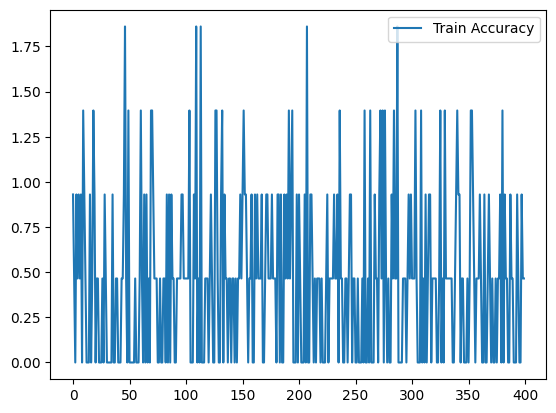

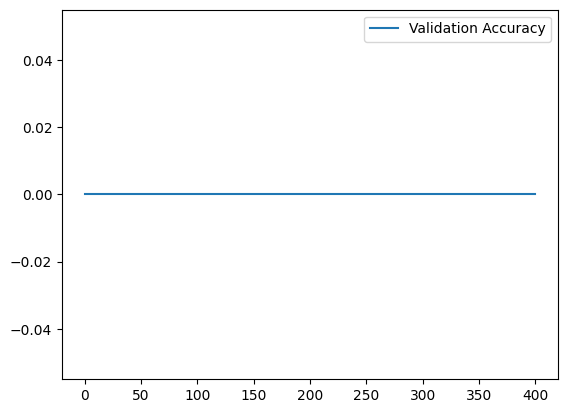

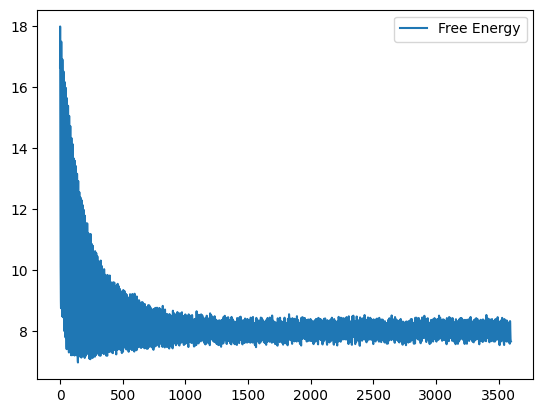

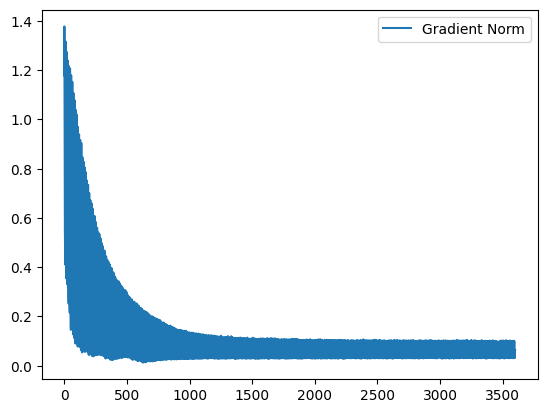

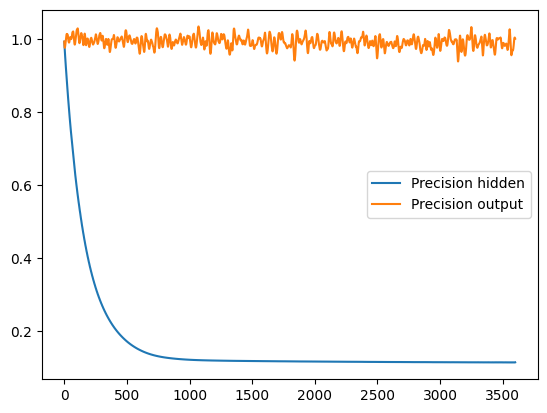

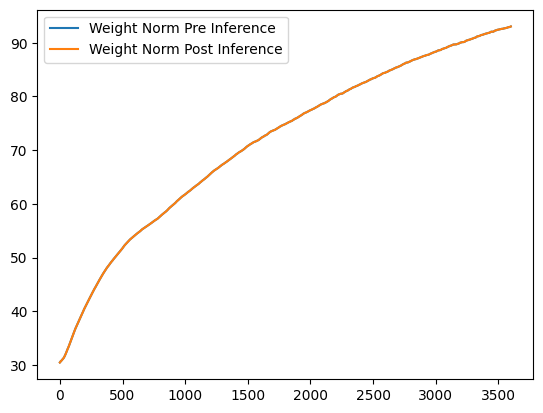

In [4]:
sns.lineplot(accuracies, label='Train Accuracy')
plt.show()
sns.lineplot(val_accuracies, label='Validation Accuracy')
plt.show()
sns.lineplot(free_energy, label='Free Energy')
plt.show()
sns.lineplot(gradients, label='Gradient Norm')
plt.show()
sns.lineplot(precisions[:, 0], label='Precision hidden')
sns.lineplot(precisions[:, 1], label='Precision output')
plt.show()
sns.lineplot(weight_norm_pre_inf, label='Weight Norm Pre Inference')
sns.lineplot(weight_norm_post_inf, label='Weight Norm Post Inference')
plt.show()


In [6]:
acc, predictions, original_words = evaluate_trace_model(model, train_dataloader, config)


In [7]:
acc

0.46511627906976744

In [8]:
for p, w in zip(predictions, original_words):
    pred_w = TraceDataset().words_padded[p.item()]
    if pred_w[:len(w)] != w:
        print(f"Predicted: {pred_w}, Original: {w}")


Predicted: p^t------, Original: si
Predicted: p^t------, Original: s^t^l
Predicted: p^t------, Original: spark
Predicted: p^t------, Original: badi
Predicted: p^t------, Original: art^st
Predicted: p^t------, Original: trup
Predicted: p^t------, Original: slip
Predicted: p^t------, Original: b^b^l
Predicted: p^t------, Original: str^k
Predicted: p^t------, Original: drap
Predicted: p^t------, Original: pradus
Predicted: p^t------, Original: st^di
Predicted: p^t------, Original: tru
Predicted: p^t------, Original: tub
Predicted: p^t------, Original: gru
Predicted: p^t------, Original: bl^S
Predicted: p^t------, Original: Sild
Predicted: p^t------, Original: pl^g
Predicted: p^t------, Original: truli
Predicted: p^t------, Original: park
Predicted: p^t------, Original: Sak
Predicted: p^t------, Original: sut
Predicted: p^t------, Original: kar
Predicted: p^t------, Original: d^st
Predicted: p^t------, Original: rak
Predicted: p^t------, Original: lak
Predicted: p^t------, Original: targ^t

## Simple inference visualization


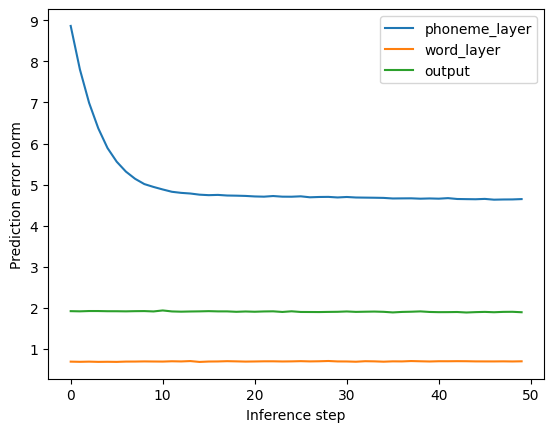

In [33]:
def pc_viz(model, input_vec, n_steps=50, step_size=0.05):
    model.eval()
    model.reset()
    model.release_clamp()

    if input_vec.ndim == 1:
        input_vec = input_vec.unsqueeze(0)
    model.layers[0].clamp(input_vec)

    layer_names = list(model.layers._modules.keys())
    errors = {name: [] for name in layer_names[1:]}

    for _ in range(n_steps):
        model.infer(n_steps=1, step_size=step_size)
        for idx in range(1, len(model.layers)):
            upper = model.layers[idx]
            lower = model.layers[idx - 1]
            prediction = upper.predict_down()
            error = (lower.state - prediction).detach()
            err_norm = error.norm(dim=tuple(range(1, error.ndim))).mean().item()
            errors[layer_names[idx]].append(err_norm)

    for name, vals in errors.items():
        plt.plot(vals, label=name)
    plt.xlabel('Inference step')
    plt.ylabel('Prediction error norm')
    plt.legend()
    plt.show()

device = model.device
words, features, labels_ind = next(iter(train_dataloader)).values()
features = features.to(device)

pc_viz(model, features[0, 0], n_steps=50, step_size=0.05)
